# Descrição do Projeto

A empresa Sweet Lift Taxi coletou dados históricos sobre pedidos de táxi nos aeroportos. Para atrair mais motoristas durante o horário de pico, precisamos prever a quantidade de pedidos de táxi para a próxima hora. 	
Construa um modelo para tal predição.

A métrica REQM no conjunto de teste não deve ser superior a 48.

Instruções do projeto

1. Faça download dos dados e faça uma nova amostragem em uma hora.
2. Analise os dados
3. Treine diferentes modelos com diferentes hiperparâmetros. A amostra de teste deve ser 10% do conjunto de dados inicial.
4. Teste os dados usando a amostra de teste e forneça uma conclusão.

Descrição dos dados

Os dados são armazenados no arquivo `taxi.csv`. O número de pedidos está na coluna `num_orders`.

# Imports e Configs Iniciais

In [68]:
# importando as bilbliotecas necessárias
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
import warnings
import re
from plotly.subplots import make_subplots

#importando Modelos de ML
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from category_encoders import CountEncoder
from statsmodels.tsa.seasonal import seasonal_decompose

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression 



from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings('ignore') # para ignorar os warnings do sklearn
from IPython.display import display # para mostrar o dataset de forma mais legível

In [69]:
pd.set_option('display.max_columns', None)

RANDOM_STATE = 42

#  📖 Dicionário de Dados: Rusty Bargain,

    
   | Coluna (no arquivo) | Nome sugerido (snake_case) | O que representa |
|---|---|---|
| datetime | date_time| Data em que o taxi foi chamado. |
| num_orders| num_orders |  **Alvo**: quantidade de pedidos realizados |



# Carregamento dos Dados

In [70]:
# importando o dataset
df = pd.read_csv('taxi.csv', index_col=0, parse_dates=['datetime'])

# visualizando as primeiras linhas do dataset
df.head()

,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32


# Pré-Processamento

In [85]:
# renomear coluna
df.rename(columns={'datetime': 'date_time'}, inplace=True)

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: h
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  4416 non-null   int64
dtypes: int64(1)
memory usage: 69.0 KB


In [87]:
df.sort_index(inplace=True)
df = df.resample('H').sum()
df.head()

,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43


In [88]:
# Verificando a data inicial e final
data_inicio = df.index.min()
data_fim = df.index.max()

print(f"Início do período: {data_inicio}")
print(f"Fim do período: {data_fim}")
print(f"Duração total: {data_fim - data_inicio}")

Início do período: 2018-03-01 00:00:00
Fim do período: 2018-08-31 23:00:00
Duração total: 183 days 23:00:00


In [89]:
# Criando um intervalo esperado completo
intervalo_esperado = pd.date_range(start=data_inicio, end=data_fim, freq='1H')

if len(df) == len(intervalo_esperado):
    print("✅ A série está completa, sem horas faltando!")
else:
    print(f"⚠️ Atenção: Faltam {len(intervalo_esperado) - len(df)} horas nos seus dados.")

✅ A série está completa, sem horas faltando!


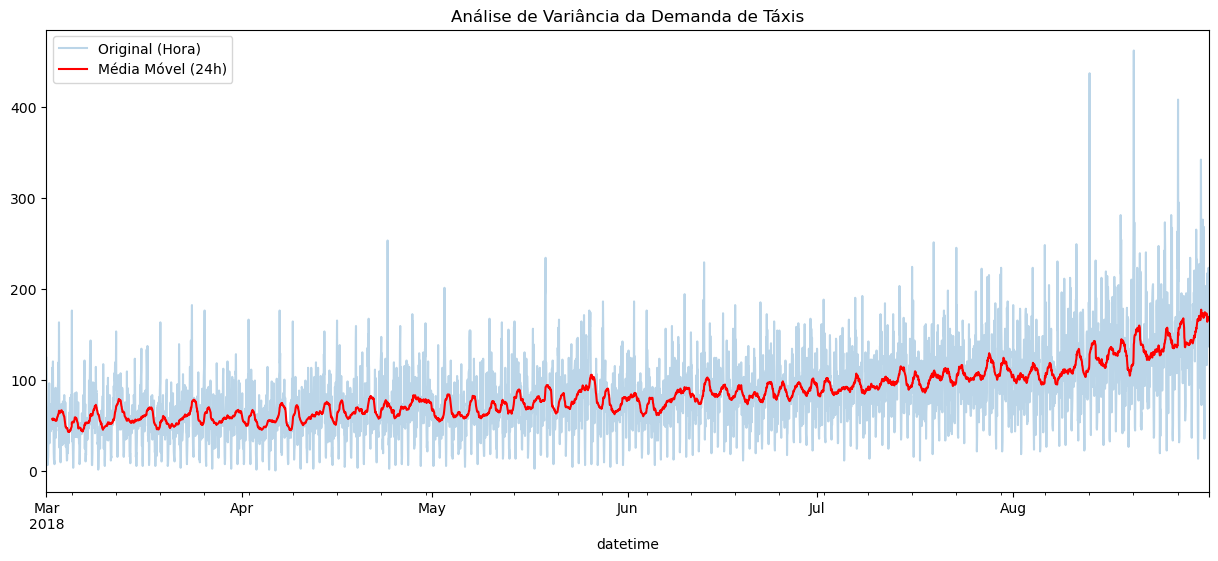

In [90]:
# Plotando os dados originais com uma média móvel para ver a tendência
plt.figure(figsize=(15, 6))
df['num_orders'].plot(alpha=0.3, label='Original (Hora)')
df['num_orders'].rolling(window=24).mean().plot(label='Média Móvel (24h)', color='red')
plt.title('Análise de Variância da Demanda de Táxis')
plt.legend()
plt.show()

- A linha vermelha mostra uma tendência de crescimento clara, especialmente a partir de julho. Isso significa que a média de pedidos está aumentando

- A série não é estacionária

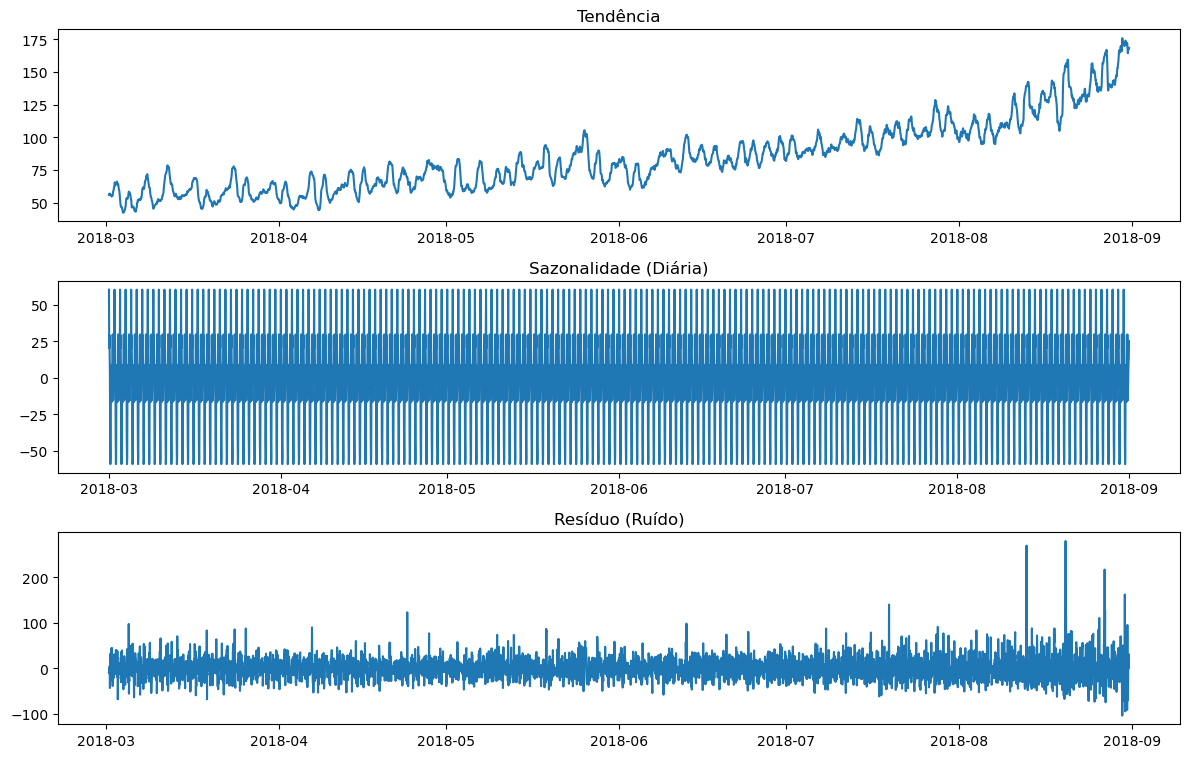

In [91]:
# Fazer a decomposição (período de 24 horas para capturar o ciclo do dia)
decomposicao = seasonal_decompose(df['num_orders'], model='additive', period=24)

# Plotar os resultados
plt.figure(figsize=(12, 10))

plt.subplot(4, 1, 2)
plt.plot(decomposicao.trend)
plt.title('Tendência')

plt.subplot(4, 1, 3)
plt.plot(decomposicao.seasonal)
plt.title('Sazonalidade (Diária)')

plt.subplot(4, 1, 4)
plt.plot(decomposicao.resid)
plt.title('Resíduo (Ruído)')

plt.tight_layout()
plt.show()

🧠 O mapa mental das features de séries temporais

Quando queremos prever um valor no tempo t, pensamos em três perguntas:

               PREVER y(t)
                   │
        ┌──────────┼──────────┐
        │          │          │
     PASSADO    CALENDÁRIO   TENDÊNCIA
      (lags)      (date)      (rolling)

In [98]:
def make_features(data, max_lag, rolling_mean_size):
    df_f = data.copy()
    
    # 1. Calendário (Date features)
    df_f['hour'] = df_f.index.hour
    df_f['day_of_week'] = df_f.index.dayofweek
    df_f['month'] = df_f.index.month
    
    # 2. Passado (Lags)
    for lag in range(1, max_lag + 1):
        df_f[f'lag_{lag}'] = df_f['num_orders'].shift(lag)
        
    # 3. Tendência (Rolling mean)
    # Importante:  shift(1)  para não "espiar" o futuro durante o treino
    df_f['rolling_mean'] = df_f['num_orders'].shift(1).rolling(rolling_mean_size).mean()
    
    return df_f.dropna() # Remove as linhas que ficaram com NaN devido ao shift

# Aplicando a função
# Exemplo: olhar 24h para trás e média móvel de 6h
df_final = make_features(df, 24, 6)

In [99]:
df_final.head()

,num_orders,hour,day_of_week,month,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,lag_13,lag_14,lag_15,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,rolling_mean
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-03-02 00:00:00,90,0,4,3,58.0,113.0,66.0,61.0,45.0,73.0,44.0,43.0,66.0,48.0,32.0,30.0,96.0,64.0,69.0,34.0,15.0,12.0,6.0,43.0,66.0,71.0,85.0,124.0,69.333333
2018-03-02 01:00:00,120,1,4,3,90.0,58.0,113.0,66.0,61.0,45.0,73.0,44.0,43.0,66.0,48.0,32.0,30.0,96.0,64.0,69.0,34.0,15.0,12.0,6.0,43.0,66.0,71.0,85.0,72.166667
2018-03-02 02:00:00,75,2,4,3,120.0,90.0,58.0,113.0,66.0,61.0,45.0,73.0,44.0,43.0,66.0,48.0,32.0,30.0,96.0,64.0,69.0,34.0,15.0,12.0,6.0,43.0,66.0,71.0,84.666667
2018-03-02 03:00:00,64,3,4,3,75.0,120.0,90.0,58.0,113.0,66.0,61.0,45.0,73.0,44.0,43.0,66.0,48.0,32.0,30.0,96.0,64.0,69.0,34.0,15.0,12.0,6.0,43.0,66.0,87.000000
2018-03-02 04:00:00,20,4,4,3,64.0,75.0,120.0,90.0,58.0,113.0,66.0,61.0,45.0,73.0,44.0,43.0,66.0,48.0,32.0,30.0,96.0,64.0,69.0,34.0,15.0,12.0,6.0,43.0,86.666667


In [94]:
# Definir o ponto de corte (10% final para teste)
train, test = train_test_split(df_final, shuffle=False, test_size=0.1)

print(f"Treino: {train.index.min()} até {train.index.max()}")
print(f"Teste: {test.index.min()} até {test.index.max()}")

Treino: 2018-03-02 00:00:00 até 2018-08-13 15:00:00
Teste: 2018-08-13 16:00:00 até 2018-08-31 23:00:00


In [95]:
X_train = train.drop(['num_orders'], axis=1)
y_train = train['num_orders']

X_test = test.drop(['num_orders'], axis=1)
y_test = test['num_orders']

## Treinamento e Teste Final

In [96]:
pipeline_dummy = Pipeline([
    ('model', DummyRegressor(strategy='mean')) # Prevê sempre a média do treino
])

In [97]:
# ---Comparação de Modelos ---

# 1. Definição dos modelos
models = {
    "Linear Regression": Pipeline([('scaler', StandardScaler()), ('lr', LinearRegression())]),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "CatBoost": CatBoostRegressor(n_estimators=100, random_state=42, verbose=0)
}

results = []

# 2. Loop de treinamento e avaliação
for name, model in models.items():
    start_time = time.time()
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    duration = time.time() - start_time
    
    results.append({
        "Model": name,
        "RMSE": round(rmse, 2),
        "Training Time (s)": round(duration, 4)
    })

# 3. Exibição elegante em uma tabela
df_results = pd.DataFrame(results).sort_values(by="RMSE")
display(df_results)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000393 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4845
[LightGBM] [Info] Number of data points in the train set: 3952, number of used features: 28
[LightGBM] [Info] Start training from score 78.451417


,Model,RMSE,Training Time (s)
4,CatBoost,38.96,0.3558
3,LightGBM,39.93,0.0955
2,XGBoost,40.93,0.4287
1,Random Forest,42.62,4.1520
0,Linear Regression,45.71,0.0377


# Revisão da checklist

- [x]  O Jupyter Notebook está aberto.

- [x]  O código está livre de erros
- [x]  As células com o código foram organizadas em ordem de execução.
- [x]  Os dados foram baixados e preparados

- [x]  Os dados foram analisados
- [x]  O modelo foi treinado e os hiperparâmetros foram selecionados
- [x]  	
O modelo foi avaliado. Uma conclusão foi fornecida

- [x] 
O REQM para o conjunto de teste não é maior que 48